# Bayesian Hierarchical Shrinkage for Portfolio Optimisation

### Question

Can Bayesian hierarchical shrinkage of expected returns improve portfolio stability and out-of-sample performance relative to classical mean-variance optimisation?

In [43]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import pymc as pm
import arviz as az

import pytensor

from sklearn.covariance import LedoitWolf

## Data fetching

In [45]:
tickers = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",
    "TLT",
    "GLD"
]

prices = yf.download(
    tickers,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

Ticker,EEM,EFA,GLD,IWM,QQQ,SPY,TLT
Date,,,,,,,
2015-01-02,30.355051,43.780636,114.080002,102.786972,94.665085,170.124985,93.001518
2015-01-05,29.814817,42.747192,115.800003,101.412811,93.276443,167.052628,94.462410
2015-01-06,29.689543,42.262978,117.120003,99.658340,92.025787,165.479156,96.164345
2015-01-07,30.331558,42.732727,116.430000,100.885582,93.212067,167.541229,95.974419
2015-01-08,30.848316,43.310883,115.940002,102.596840,94.996132,170.514236,94.703491


## Calculating Returns

In [46]:
returns = np.log(
    prices / prices.shift(1)
).dropna()

returns.head()

Ticker,EEM,EFA,GLD,IWM,QQQ,SPY,TLT
Date,,,,,,,
2015-01-05,-0.017957,-0.023888,0.014965,-0.013459,-0.014778,-0.018224,0.015586
2015-01-06,-0.004211,-0.011392,0.011334,-0.017452,-0.013499,-0.009464,0.017857
2015-01-07,0.021394,0.011054,-0.005909,0.012239,0.012808,0.012384,-0.001977
2015-01-08,0.016893,0.013439,-0.004217,0.016820,0.018959,0.017589,-0.013331
2015-01-09,-0.003305,-0.004851,0.011321,-0.009650,-0.006605,-0.008046,0.010893


## Data summary

In [47]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
EEM,2873.0,0.000269,0.013137,-0.133294,-0.006529,0.000736,0.007588,0.077451
EFA,2873.0,0.000297,0.010945,-0.116424,-0.004716,0.000614,0.005921,0.081332
GLD,2873.0,0.000434,0.010054,-0.108412,-0.004720,0.000557,0.005518,0.061647
IWM,2873.0,0.000354,0.014208,-0.142335,-0.006946,0.000887,0.008230,0.087545
QQQ,2873.0,0.000704,0.013807,-0.127592,-0.005014,0.001230,0.007813,0.113356
SPY,2873.0,0.000511,0.011145,-0.115886,-0.003685,0.000658,0.005912,0.099863
TLT,2873.0,-0.000033,0.009365,-0.069011,-0.005635,0.000337,0.005477,0.072502


## Plot

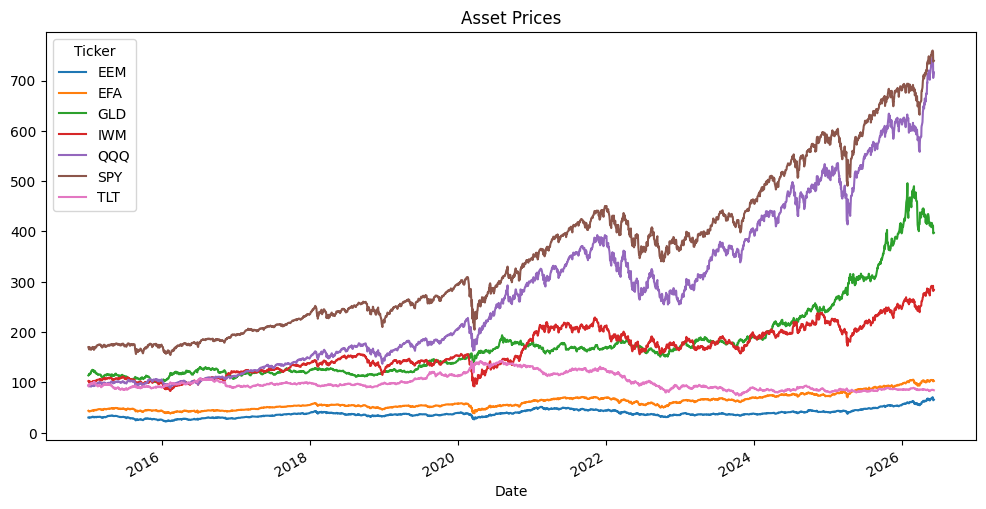

In [48]:
prices.plot(
    figsize=(12,6),
    title="Asset Prices"
)

plt.show()

## Exploratory Data Analysis

In [49]:
corr_matrix = returns.corr()

corr_matrix

Ticker,EEM,EFA,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,,,
EEM,1.000000,0.832634,0.200580,0.696045,0.725023,0.752189,-0.120643
EFA,0.832634,1.000000,0.165519,0.789211,0.753609,0.846000,-0.140878
GLD,0.200580,0.165519,1.000000,0.071626,0.072064,0.061059,0.260638
IWM,0.696045,0.789211,0.071626,1.000000,0.771718,0.868497,-0.150556
QQQ,0.725023,0.753609,0.072064,0.771718,1.000000,0.933824,-0.121817
SPY,0.752189,0.846000,0.061059,0.868497,0.933824,1.000000,-0.174181
TLT,-0.120643,-0.140878,0.260638,-0.150556,-0.121817,-0.174181,1.000000


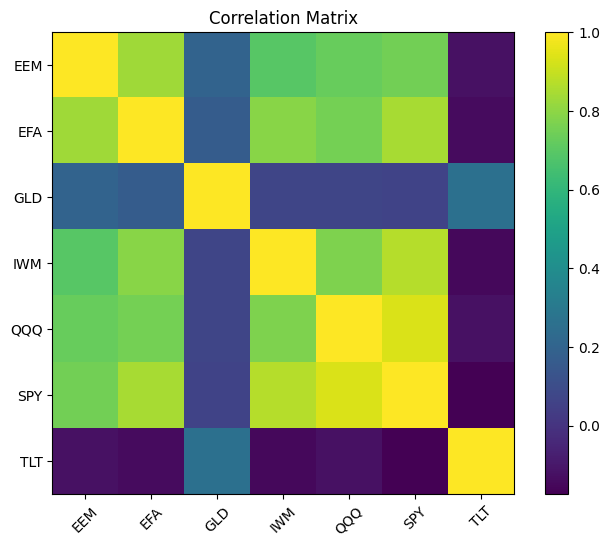

In [50]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Classical Mean-Variance Optimisation

In [51]:
returns_recent = returns.tail(252 * 3)

mu_recent = returns_recent.mean() * 252
cov_recent = returns_recent.cov() * 252

mu_recent, cov_recent

(Ticker
 EEM    0.199883
 EFA    0.152463
 GLD    0.256995
 IWM    0.172210
 QQQ    0.242567
 SPY    0.199813
 TLT   -0.024590
 dtype: float64,
 Ticker       EEM       EFA       GLD       IWM       QQQ       SPY       TLT
 Ticker                                                                      
 EEM     0.034199  0.022609  0.014339  0.024911  0.025192  0.019207  0.004601
 EFA     0.022609  0.022948  0.010727  0.022976  0.020720  0.017364  0.005548
 GLD     0.014339  0.010727  0.040616  0.008200  0.006176  0.004688  0.004224
 IWM     0.024911  0.022976  0.008200  0.045134  0.029834  0.025873  0.005896
 QQQ     0.025192  0.020720  0.006176  0.029834  0.039023  0.028347  0.002934
 SPY     0.019207  0.017364  0.004688  0.025873  0.028347  0.022764  0.003122
 TLT     0.004601  0.005548  0.004224  0.005896  0.002934  0.003122  0.019411)

## Equal Weight Portfolio

In [52]:
n_assets = len(mu_recent)

equal_weights = np.repeat(
    1 / n_assets,
    n_assets
)

equal_weights

array([0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714])

In [53]:
equal_return = np.dot(
    equal_weights,
    mu_recent
)

equal_return

0.17133450370153444

In [54]:
equal_vol = np.sqrt(
    equal_weights.T
    @ cov_recent
    @ equal_weights
)

equal_vol

0.13085810478639662

In [55]:
#assumption
risk_free_rate = 0.02

equal_sharpe = (
    equal_return - risk_free_rate
) / equal_vol

equal_sharpe

1.1564778807438947

## Maximum Sharpe Portfolio (Markowitz)

In [56]:
from scipy.optimize import minimize

In [57]:
def portfolio_stats(weights, mu_recent, cov_recent):

    port_return = np.dot(weights, mu_recent)

    port_vol = np.sqrt(
        weights.T @ cov_recent @ weights
    )

    sharpe = (
        port_return - risk_free_rate
    ) / port_vol

    return port_return, port_vol, sharpe

In [58]:
# to maximise sharpe ratio
def negative_sharpe(weights, mu, cov):

    return -portfolio_stats(
        weights,
        mu,
        cov
    )[2]

In [59]:
n_assets = len(mu_recent)

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = tuple(
    (0, 1)
    for _ in range(n_assets)
)

initial_weights = np.repeat(
    1 / n_assets,
    n_assets
)

In [60]:
# optimise
result = minimize(
    negative_sharpe,
    initial_weights,
    args=(mu_recent, cov_recent),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

maximised_weights = result.x

pd.Series(
    maximised_weights,
    index=mu_recent.index
).sort_values(
    ascending=False
)

Ticker
SPY    0.576408
GLD    0.423592
EEM    0.000000
EFA    0.000000
IWM    0.000000
QQQ    0.000000
TLT    0.000000
dtype: float64

## Covariance Shrinkage (Ledoit-Wolf)

In [61]:
lw = LedoitWolf()

lw.fit(returns_recent)

cov_lw_recent = pd.DataFrame(
    lw.covariance_ * 252,
    index=returns_recent.columns,
    columns=returns_recent.columns
)

cov_lw_recent.head()

Ticker,EEM,EFA,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,,,
EEM,0.034094,0.021954,0.013924,0.024191,0.024463,0.018651,0.004468
EFA,0.021954,0.023168,0.010416,0.022311,0.020121,0.016861,0.005387
GLD,0.013924,0.010416,0.040325,0.007962,0.005997,0.004552,0.004102
IWM,0.024191,0.022311,0.007962,0.044712,0.028970,0.025124,0.005725
QQQ,0.024463,0.020121,0.005997,0.028970,0.038778,0.027526,0.002849


In [62]:
# optimise
result = minimize(
    negative_sharpe,
    initial_weights,
    args=(mu_recent, cov_lw_recent),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

maximised_lw_weights = result.x

pd.Series(
    maximised_lw_weights,
    index=mu_recent.index
).sort_values(
    ascending=False
)

Ticker
SPY    5.009420e-01
GLD    4.335381e-01
QQQ    6.551988e-02
TLT    1.812638e-16
IWM    5.300771e-17
EEM    1.204659e-17
EFA    0.000000e+00
dtype: float64

### Summary

The Markowitz and Ledoit-Wolf portfolios allocate almost all capital to QQQ and GLD

The optimiser treats sample estimates of expected returns as precise, despite the fact that expected returns are notoriously difficult to estimate accurately.

These findings motivate the use of Bayesian hierarchical shrinkage, which partially pools information across assets and shrinks extreme return estimates toward a common market-level mean. The objective is to obtain more robust expected return estimates and, consequently, more stable portfolio allocations.

## Bayesian Hierarchical Shrinkage of Expected Returns

In [63]:
mu_recent.mean()

0.17133450370153444

In [64]:
mu_recent.sort_values(ascending=False)

Ticker
GLD    0.256995
QQQ    0.242567
EEM    0.199883
SPY    0.199813
IWM    0.172210
EFA    0.152463
TLT   -0.024590
dtype: float64

## Bayesian Hierarchical Shrinkage Model

In [66]:
#last 3 years of data
returns_recent = returns.tail(252 * 3)

returns_model = returns_recent
sample_means = returns_recent.mean() * 252

In [78]:
with pm.Model() as hierarchical_model:

    mu_global = pm.Normal(
        "mu_global",
        mu=0,
        sigma=0.20
    )

    tau = pm.HalfNormal(
        "tau",
        sigma=0.10
    )

    z_asset = pm.Normal(
        "z_asset",
        mu=0,
        sigma=1,
        shape=len(sample_means)
    )

    mu_asset = pm.Deterministic(
        "mu_asset",
        mu_global + tau * z_asset
    )

    obs = pm.Normal(
        "obs",
        mu=mu_asset,
        sigma=np.std(sample_means.values),
        observed=sample_means.values
    )

In [81]:
with hierarchical_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.99,
        random_seed=42
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, tau, z_asset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 108 seconds.


## Results

In [83]:
az.summary(
    trace,
    var_names=["mu_global", "tau", "mu_asset"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,0.165,0.040,0.092,0.242,0.001,0.001,2309.0,2175.0,1.0
tau,0.053,0.039,0.000,0.121,0.001,0.001,1645.0,1816.0,1.0
mu_asset[0],0.174,0.054,0.072,0.280,0.001,0.001,4638.0,3420.0,1.0
mu_asset[1],0.161,0.052,0.057,0.254,0.001,0.001,4403.0,3245.0,1.0
mu_asset[2],0.189,0.055,0.092,0.299,0.001,0.001,3853.0,3029.0,1.0
mu_asset[3],0.167,0.051,0.074,0.269,0.001,0.001,4131.0,3607.0,1.0
mu_asset[4],0.186,0.056,0.085,0.295,0.001,0.001,4145.0,3475.0,1.0
mu_asset[5],0.175,0.053,0.075,0.275,0.001,0.001,4030.0,3633.0,1.0
mu_asset[6],0.116,0.067,-0.020,0.226,0.001,0.001,2771.0,3199.0,1.0


In [84]:
bayesian_mu = pd.Series(
    trace.posterior["mu_asset"]
    .mean(dim=["chain", "draw"])
    .values,
    index=sample_means.index
)

comparison = pd.DataFrame({
    "Sample Mean": sample_means,
    "Bayesian Mean": bayesian_mu
})

comparison["Shrinkage"] = (
    comparison["Bayesian Mean"]
    - comparison["Sample Mean"]
)

comparison.sort_values(
    "Sample Mean",
    ascending=False
)

,Sample Mean,Bayesian Mean,Shrinkage
Ticker,,,
GLD,0.256995,0.188737,-0.068258
QQQ,0.242567,0.186170,-0.056397
EEM,0.199883,0.173952,-0.025931
SPY,0.199813,0.175310,-0.024503
IWM,0.172210,0.166682,-0.005528
EFA,0.152463,0.160782,0.008319
TLT,-0.024590,0.115628,0.140218


The hierarchical Bayesian model shrinks asset-specific expected returns toward a common global mean. Extreme estimates such as EEM, IWM and QQQ are moderated downward, while lower-return assets such as TLT and EFA are adjusted upward. This behaviour reduces estimation noise and overconfidence in historical sample means, which are known to be unstable inputs for mean-variance optimisation.

## Bayesian Shrinkage Portfolio

In [85]:
result = minimize(
    negative_sharpe,
    initial_weights,
    args=(bayesian_mu, cov_lw_recent),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

bayesian_weights = result.x

pd.Series(
    bayesian_weights,
    index=bayesian_mu.index
).sort_values(ascending=False)

Ticker
SPY    4.661027e-01
TLT    2.710399e-01
GLD    2.628574e-01
EFA    8.991499e-17
EEM    0.000000e+00
IWM    0.000000e+00
QQQ    0.000000e+00
dtype: float64

In [86]:
bayesian_return, bayesian_vol, bayesian_sharpe = portfolio_stats(
    bayesian_weights,
    bayesian_mu,
    cov_lw_recent
)

bayesian_return, bayesian_vol, bayesian_sharpe

(0.1626634758347226, 0.10814928784974774, 1.3191346764384206)

## Portfolio Comparison

In [87]:
classical_return, classical_vol, classical_sharpe = portfolio_stats(
    maximised_weights,
    mu_recent,
    cov_recent
)

lw_return, lw_vol, lw_sharpe = portfolio_stats(
    maximised_lw_weights,
    mu_recent,
    cov_lw_recent
)

bayesian_return, bayesian_vol, bayesian_sharpe = portfolio_stats(
    bayesian_weights,
    bayesian_mu,
    cov_lw_recent
)

In [88]:
comparison = pd.DataFrame({
    "Expected Return": [
        classical_return,
        lw_return,
        bayesian_return
    ],
    "Volatility": [
        classical_vol,
        lw_vol,
        bayesian_vol
    ],
    "Sharpe Ratio": [
        classical_sharpe,
        lw_sharpe,
        bayesian_sharpe
    ]
},
index=[
    "Classical",
    "Ledoit-Wolf",
    "Bayesian + Ledoit-Wolf"
])

comparison

,Expected Return,Volatility,Sharpe Ratio
Classical,0.224035,0.130921,1.558458
Ledoit-Wolf,0.227405,0.132815,1.561610
Bayesian + Ledoit-Wolf,0.162663,0.108149,1.319135


In [89]:
weights_comparison = pd.DataFrame({
    "Classical": maximised_weights,
    "Ledoit-Wolf": maximised_lw_weights,
    "Bayesian": bayesian_weights
}, index=returns_recent.columns)

weights_comparison

,Classical,Ledoit-Wolf,Bayesian
Ticker,,,
EEM,0.000000,1.204659e-17,0.000000e+00
EFA,0.000000,0.000000e+00,8.991499e-17
GLD,0.423592,4.335381e-01,2.628574e-01
IWM,0.000000,5.300771e-17,0.000000e+00
QQQ,0.000000,6.551988e-02,0.000000e+00
SPY,0.576408,5.009420e-01,4.661027e-01
TLT,0.000000,1.812638e-16,2.710399e-01


In [90]:
pd.DataFrame({
    "Sample": mu_recent,
    "Bayesian": bayesian_mu
}).sort_values("Sample", ascending=False)

,Sample,Bayesian
Ticker,,
GLD,0.256995,0.188737
QQQ,0.242567,0.186170
EEM,0.199883,0.173952
SPY,0.199813,0.175310
IWM,0.172210,0.166682
EFA,0.152463,0.160782
TLT,-0.024590,0.115628


In [91]:
sample_means.std()

0.09379147581148